# Receipt Credit Card Agent Comparison Notebook

This notebook compares full pipeline variants on the same receipt:

1. `Version 1` = `tesseract` perception + `planning v1` classical classification
2. `Version 2` = `paddleocr` perception + `planning v2` transformer-based classification
3. `Experimental TrOCR` = `trocr` perception + `planning v2` transformer-based classification
4. `Labels Reference` = dataset-provided `labels` text + configurable planning version

All three share the same LLM control phase with live web research through `tool_registry`.


In [2]:
from pathlib import Path
import base64
import html
import importlib
import json
import sys
from io import BytesIO

import pandas as pd
from PIL import Image
from IPython.display import HTML, Markdown, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.perception as perception_module
import src.planning as planning_module
import src.control as control_module
import src.utils as utils_module

importlib.reload(perception_module)
importlib.reload(planning_module)
importlib.reload(control_module)
importlib.reload(utils_module)

ReceiptPerception = perception_module.ReceiptPerception
ReceiptPlanner = planning_module.ReceiptPlanner
CreditCardRecommender = control_module.CreditCardRecommender
preferred_receipts_dir = utils_module.preferred_receipts_dir
preferred_labeled_receipts_dir = utils_module.preferred_labeled_receipts_dir
list_receipt_images = utils_module.list_receipt_images
has_reference_labels = utils_module.has_reference_labels


## Settings

In [3]:
receipts_dir = preferred_receipts_dir()
receipt_candidates = list_receipt_images(receipts_dir)
if not receipt_candidates:
    raise FileNotFoundError(f'No receipt images found in: {receipts_dir}')

receipt_path = receipt_candidates[0]
pipeline_configs = [
    {
        'label': 'version_1_non_dl',
        'perception_method': 'tesseract',
        'planning_version': 'v1',
    },
    {
        'label': 'version_2_dl',
        'perception_method': 'paddleocr',
        'planning_version': 'v2',
    },
    {
        'label': 'experimental_trocr',
        'perception_method': 'trocr',
        'planning_version': 'v2',
    },
]

if has_reference_labels(receipt_path):
    pipeline_configs.append({
        'label': 'labels_reference',
        'perception_method': 'labels',
        'planning_version': 'v2',
    })

run_control = True

receipt_path


PosixPath('/Users/aeshagandhi/Downloads/MIDS-Sp26/Agents/Credit-Card-Agent/data/receipt_dataset/ds0/img/1007-receipt.jpg')

## View Selected Receipt

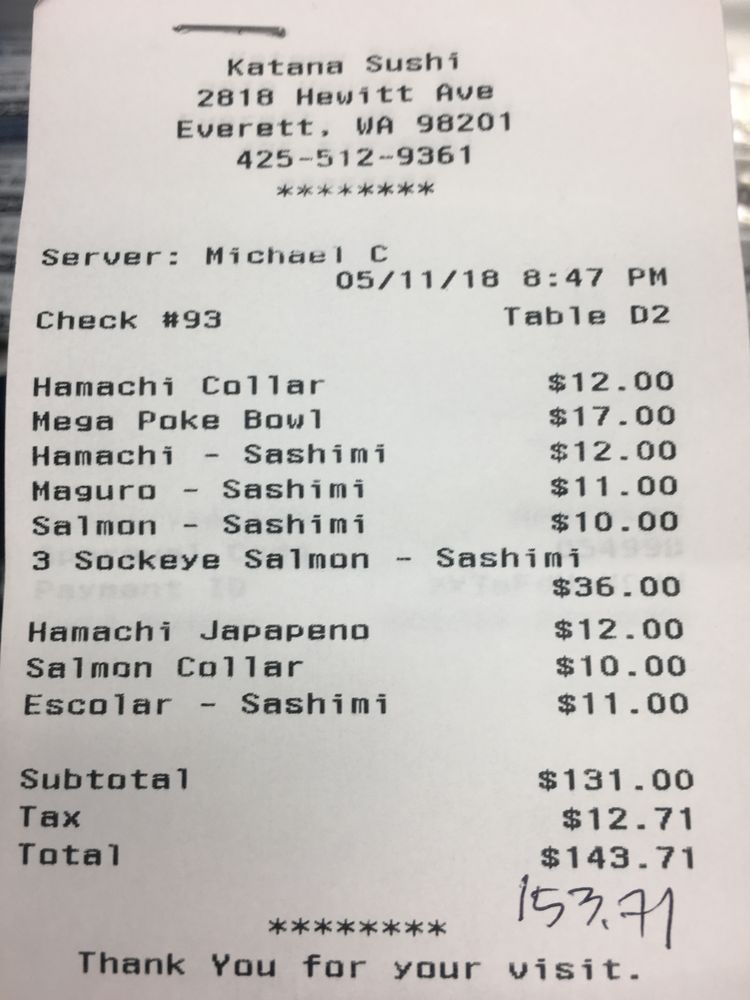

Image size: (750, 1000)


In [4]:
receipt_image = Image.open(receipt_path)
display(receipt_image)
print('Image size:', receipt_image.size)

## Initialize Pipeline

In [5]:
perception = ReceiptPerception()
planner = ReceiptPlanner()
recommender = CreditCardRecommender() if run_control else None

## Helper Functions

In [6]:
def run_pipeline_config(image_path, config, run_control=True):
    try:
        ocr_result = perception.extract_text(image_path, method=config['perception_method'])
        spending_profile = planner.build_spending_profile(ocr_result.text, version=config['planning_version'])
        recommendation = recommender.recommend_card(spending_profile) if run_control else None
        return {
            'label': config['label'],
            'perception_method': config['perception_method'],
            'planning_version': config['planning_version'],
            'status': 'ok',
            'error': None,
            'ocr_result': ocr_result,
            'spending_profile': spending_profile,
            'recommendation': recommendation,
        }
    except Exception as exc:
        return {
            'label': config['label'],
            'perception_method': config['perception_method'],
            'planning_version': config['planning_version'],
            'status': 'error',
            'error': str(exc),
            'ocr_result': None,
            'spending_profile': None,
            'recommendation': None,
        }


def summarize_result(result):
    if result['status'] != 'ok':
        return {
            'label': result['label'],
            'perception_method': result['perception_method'],
            'planning_version': result['planning_version'],
            'status': 'error',
            'error': result['error'],
            'merchant': None,
            'total_amount': None,
            'line_item_count': None,
            'non_zero_categories': None,
            'primary_card': None,
            'primary_issuer': None,
            'estimated_value': None,
        }

    profile = result['spending_profile']
    recommendation = result['recommendation']
    non_zero_categories = [
        f"{key}: {value:.2f}"
        for key, value in profile.category_totals.items()
        if value > 0
    ]
    return {
        'label': result['label'],
        'perception_method': result['perception_method'],
        'planning_version': result['planning_version'],
        'status': 'ok',
        'error': None,
        'merchant': profile.merchant,
        'total_amount': profile.total_amount,
        'line_item_count': len(profile.line_items),
        'non_zero_categories': ', '.join(non_zero_categories) if non_zero_categories else '[none]',
        'primary_card': recommendation.primary_card if recommendation else '[skipped]',
        'primary_issuer': recommendation.primary_issuer if recommendation else '[skipped]',
        'estimated_value': recommendation.primary_estimated_value if recommendation else None,
    }


def thumbnail_html(image_path, width=220, max_height=700):
    image = Image.open(image_path).convert('RGB')
    thumbnail = image.copy()
    thumbnail.thumbnail((width, max_height))
    buffer = BytesIO()
    thumbnail.save(buffer, format='JPEG')
    encoded = base64.b64encode(buffer.getvalue()).decode('utf-8')
    return (
        f'<img src="data:image/jpeg;base64,{encoded}" ' 
        f'style="width:{thumbnail.width}px; border:1px solid #ddd; border-radius:6px;" />'
    )


def parsed_text_html(text, width=420, max_height=320):
    safe_text = html.escape(text or '')
    return (
        f'<div style="width:{width}px; max-height:{max_height}px; overflow:auto; ' 
        'white-space:pre-wrap; font-family:monospace; font-size:12px; line-height:1.35; ' 
        'border:1px solid #ddd; border-radius:6px; padding:8px; background:#fafafa;">'
        f'{safe_text}</div>'
    )


## Run Pipeline Variants on One Receipt


In [7]:
results = [run_pipeline_config(receipt_path, config, run_control=run_control) for config in pipeline_configs]
summary_df = pd.DataFrame([summarize_result(result) for result in results])
display(summary_df)


/Users/aeshagandhi/Downloads/MIDS-Sp26/Agents/Credit-Card-Agent/.venv/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/aeshagandhi/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/aeshagandhi/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/aeshagandhi/.paddlex/official_models/PP-LCNet_x1_0_text

,label,perception_method,planning_version,status,error,merchant,total_amount,line_item_count,non_zero_categories,primary_card,primary_issuer,estimated_value
0,version_1_non_dl,tesseract,v1,ok,None,——wy ',131.00,9,other: 131.00,Chase Freedom Unlimited®,Chase,6.55
1,version_2_dl,paddleocr,v2,ok,None,Katana Sushi,576.13,13,other: 576.13,Blue Cash Preferred® Card from American Express,American Express,34.57
2,experimental_trocr,trocr,v2,ok,None,1,0.00,0,[none],Wells Fargo Active Cash® Card,Wells Fargo,400.00
3,labels_reference,labels,v2,ok,None,Katana Sushi,126.00,9,other: 126.00,American Express® Gold Card,American Express,6.30


## OCR Text Previews

In [8]:
for result in results:
    heading = f"### {result['label']} ({result['perception_method']} + {result['planning_version']})"
    display(Markdown(heading))
    if result['status'] != 'ok':
        print('ERROR:', result['error'])
        print()
        continue

    preview = result['ocr_result'].text[:2000] if result['ocr_result'].text else '[No text extracted]'
    print(preview)
    print()


### version_1_non_dl (tesseract + v1)

——wy '
| Katana Sushi
~~ 2819 Hewitt Ave >
Everett. WA 98201 ~
425-512-9361 .
. 2 A FOR HO
.
Server: Michel C
05/11/18 68:47 PM
Check #93 Table D2
Hamachi Collar $12.00
Mega Poke Bowl $17.00
Hamachi - Sashimi $12.00
Magura - Sashimi $11.00
Salmon - Sashimi $10.00
3 Sockeye Salmon - Sashimi
$36.00
Hamachi Japapeno $12.00
Salmon Collar $10.00
Escolar - Sashimi $11.00
Subtotal $131.00
Tax $12.71
Total $143.71
FAK KOK 4K IS2y
Thank You for your visit.



### version_2_dl (paddleocr + v2)

Katana Sushi
2818 Hewitt Ave
Everett, WA 98201
425-512-9361
********
Server: Michael C
05/11/18 8:47 PM
Check #93
Table D2
Hamachi Collar
$12.00
Mega Poke Bowl
$17.00
Hamachi
i- Sashimi
$12.00
Maguro - Sashimi
$11.00
Salmon - Sashimi
$10.00
3 Sockeye Salmon
- Sashimi
$36.00
Hamachi Japapeno
$12.00
Salmon Collar
$10.00
Escolar - Sashimi
$11.00
Subtotal
$131.00
Tax
$12.71
Total
$143.71
157.71
*********
Thank You for your



### experimental_trocr (trocr + v2)

1



### labels_reference (labels + v2)

Katana Sushi
2818 Hewitt Ave
Everett, WA 98201
425-512-9361
********
Server: Michael C
05/11/18/ 8:47 PM
Check #93 Table D2
Hamachi Collar $12.00
Mag Pke Bowl $12.00
Hamachi - Sashimi $12.00
Maguro - Sashimi $11.00
Salmon - Sashimi $10.00
3 Sockeye Salmon - Sashimi
$36.00
Hamachi Jappapeno $12.00
Salmon Collar $10.00
Escolar -Sashimi $11.00
Subtotal $131.00
Tax $12.71
Total $143.71
******** 153,71
Thank You for your visit .



## Spending Profile Comparison

In [9]:
profiles_df = pd.DataFrame([
    {
        'label': result['label'],
        'perception_method': result['perception_method'],
        'planning_version': result['planning_version'],
        'status': result['status'],
        'merchant': result['spending_profile'].merchant if result['status'] == 'ok' else None,
        'groceries': result['spending_profile'].category_totals['groceries'] if result['status'] == 'ok' else None,
        'dining': result['spending_profile'].category_totals['dining'] if result['status'] == 'ok' else None,
        'travel': result['spending_profile'].category_totals['travel'] if result['status'] == 'ok' else None,
        'gas': result['spending_profile'].category_totals['gas'] if result['status'] == 'ok' else None,
        'entertainment': result['spending_profile'].category_totals['entertainment'] if result['status'] == 'ok' else None,
        'shopping': result['spending_profile'].category_totals['shopping'] if result['status'] == 'ok' else None,
        'healthcare': result['spending_profile'].category_totals['healthcare'] if result['status'] == 'ok' else None,
        'other': result['spending_profile'].category_totals['other'] if result['status'] == 'ok' else None,
        'total_amount': result['spending_profile'].total_amount if result['status'] == 'ok' else None,
        'line_item_count': len(result['spending_profile'].line_items) if result['status'] == 'ok' else None,
    }
    for result in results
])
display(profiles_df)


,label,perception_method,planning_version,status,merchant,groceries,dining,travel,gas,entertainment,shopping,healthcare,other,total_amount,line_item_count
0,version_1_non_dl,tesseract,v1,ok,——wy ',0.0,0.0,0.0,0.0,0.0,0.0,0.0,131.00,131.00,9
1,version_2_dl,paddleocr,v2,ok,Katana Sushi,0.0,0.0,0.0,0.0,0.0,0.0,0.0,576.13,576.13,13
2,experimental_trocr,trocr,v2,ok,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0
3,labels_reference,labels,v2,ok,Katana Sushi,0.0,0.0,0.0,0.0,0.0,0.0,0.0,126.00,126.00,9


## Recommendation Comparison

In [10]:
if run_control:
    recommendations_df = pd.DataFrame([
        {
            'label': result['label'],
            'perception_method': result['perception_method'],
            'planning_version': result['planning_version'],
            'status': result['status'],
            'primary_card': result['recommendation'].primary_card if result['status'] == 'ok' and result['recommendation'] else None,
            'primary_issuer': result['recommendation'].primary_issuer if result['status'] == 'ok' and result['recommendation'] else None,
            'primary_value': result['recommendation'].primary_estimated_value if result['status'] == 'ok' and result['recommendation'] else None,
            'runner_up_card': result['recommendation'].runner_up_card if result['status'] == 'ok' and result['recommendation'] else None,
            'runner_up_issuer': result['recommendation'].runner_up_issuer if result['status'] == 'ok' and result['recommendation'] else None,
            'runner_up_value': result['recommendation'].runner_up_estimated_value if result['status'] == 'ok' and result['recommendation'] else None,
        }
        for result in results
    ])
    display(recommendations_df)
else:
    print('Control step skipped.')


,label,perception_method,planning_version,status,primary_card,primary_issuer,primary_value,runner_up_card,runner_up_issuer,runner_up_value
0,version_1_non_dl,tesseract,v1,ok,Chase Freedom Unlimited®,Chase,6.55,Capital One Savor Cash Rewards Credit Card,Capital One,3.93
1,version_2_dl,paddleocr,v2,ok,Blue Cash Preferred® Card from American Express,American Express,34.57,Citi Double Cash,Citi,11.52
2,experimental_trocr,trocr,v2,ok,Wells Fargo Active Cash® Card,Wells Fargo,400.00,Citi Double Cash® Card,Citi,300.00
3,labels_reference,labels,v2,ok,American Express® Gold Card,American Express,6.30,Capital One SavorOne Cash Rewards Credit Card,Capital One,3.78


## Full Structured Output for One Method

In [11]:
available_labels = [result['label'] for result in results]
selected_pipeline_label = 'labels_reference' if 'labels_reference' in available_labels else available_labels[0]
selected_result = next(result for result in results if result['label'] == selected_pipeline_label)

if selected_result['status'] != 'ok':
    print('ERROR:', selected_result['error'])
else:
    combined_output = {
        'pipeline': {
            'label': selected_result['label'],
            'perception_method': selected_result['perception_method'],
            'planning_version': selected_result['planning_version'],
        },
        'ocr': {
            'method': selected_result['ocr_result'].method,
            'image_path': selected_result['ocr_result'].image_path,
            'confidence': selected_result['ocr_result'].confidence,
            'metadata': selected_result['ocr_result'].metadata,
            'text': selected_result['ocr_result'].text,
        },
        'planning': selected_result['spending_profile'].as_dict(),
        'control': selected_result['recommendation'].as_dict() if selected_result['recommendation'] else None,
    }
    print(json.dumps(combined_output, indent=2))


{
  "pipeline": {
    "label": "labels_reference",
    "perception_method": "labels",
    "planning_version": "v2"
  },
  "ocr": {
    "method": "labels",
    "image_path": "/Users/aeshagandhi/Downloads/MIDS-Sp26/Agents/Credit-Card-Agent/data/receipt_dataset/ds0/img/1007-receipt.jpg",
    "confidence": 1.0,
    "metadata": {
      "source": "local receipt_dataset annotation json",
      "annotation_path": "/Users/aeshagandhi/Downloads/MIDS-Sp26/Agents/Credit-Card-Agent/data/receipt_dataset/ds0/ann/1007-receipt.jpg.json",
      "categories": [
        "Business address",
        "Business name",
        "Business phone",
        "Item information",
        "Other",
        "Subtotal",
        "Tax",
        "Time and date",
        "Total"
      ]
    },
    "text": "Katana Sushi\n2818 Hewitt Ave\nEverett, WA 98201\n425-512-9361\n********\nServer: Michael C\n05/11/18/ 8:47 PM\nCheck #93 Table D2\nHamachi Collar $12.00\nMag Pke Bowl $12.00\nHamachi - Sashimi $12.00\nMaguro - Sashimi $11.

## Batch Comparison Across a Few Receipts

image,receipt,label,perception_method,planning_version,parsed_text,status,merchant,total_amount,line_item_count,primary_card,estimated_value,error
,1007-receipt.jpg,version_1_non_dl,tesseract,v1,——wy '\n| Katana Sushi\n~~ 2819 Hewitt Ave >\nEverett. WA 98201 ~\n425-512-9361 .\n. 2 A FOR HO\n.\nServer: Michel C\n05/11/18 68:47 PM\nCheck #93 Table D2\nHamachi Collar $12.00\nMega Poke Bowl $17.00\nHamachi - Sashimi $12.00\nMagura - Sashimi $11.00\nSalmon - Sashimi $10.00\n3 Sockeye Salmon - Sashimi\n$36.00\nHamachi Japapeno $12.00\nSalmon Collar $10.00\nEscolar - Sashimi $11.00\nSubtotal $131.00\nTax $12.71\nTotal $143.71\nFAK KOK 4K IS2y\nThank You for your visit.,ok,——wy ',131.00,9.0,Wells Fargo Active Cash® Card,262.0000,NaN
,1007-receipt.jpg,version_2_dl,paddleocr,v2,"Katana Sushi\n2818 Hewitt Ave\nEverett, WA 98201\n425-512-9361\n********\nServer: Michael C\n05/11/18 8:47 PM\nCheck #93\nTable D2\nHamachi Collar\n$12.00\nMega Poke Bowl\n$17.00\nHamachi\ni- Sashimi\n$12.00\nMaguro - Sashimi\n$11.00\nSalmon - Sashimi\n$10.00\n3 Sockeye Salmon\n- Sashimi\n$36.00\nHamachi Japapeno\n$12.00\nSalmon Collar\n$10.00\nEscolar - Sashimi\n$11.00\nSubtotal\n$131.00\nTax\n$12.71\nTotal\n$143.71\n157.71\n*********\nThank You for your",ok,Katana Sushi,576.13,13.0,Chase Sapphire Preferred® Card,23.0452,NaN
,1007-receipt.jpg,experimental_trocr,trocr,v2,1,ok,1,0.00,0.0,Wells Fargo Active Cash® Card,1200.0000,NaN
,1007-receipt.jpg,labels_reference,labels,v2,"Katana Sushi\n2818 Hewitt Ave\nEverett, WA 98201\n425-512-9361\n********\nServer: Michael C\n05/11/18/ 8:47 PM\nCheck #93 Table D2\nHamachi Collar $12.00\nMag Pke Bowl $12.00\nHamachi - Sashimi $12.00\nMaguro - Sashimi $11.00\nSalmon - Sashimi $10.00\n3 Sockeye Salmon - Sashimi\n$36.00\nHamachi Jappapeno $12.00\nSalmon Collar $10.00\nEscolar -Sashimi $11.00\nSubtotal $131.00\nTax $12.71\nTotal $143.71\n******** 153,71\nThank You for your visit .",ok,Katana Sushi,126.00,9.0,American Express® Gold Card,309.0400,NaN
,1008-receipt.jpg,version_1_non_dl,tesseract,v1,Dona Mercedes Restaurant | rt {7\nf 1030 1/2 San Fernando Rd noo\nao ee San Fernando CA 91341 —_\na it iN\nsali Vero i Ls\naaa CENTERL ‘ io\naH 1 CHicharon $2.25 JV\na 3 Pupusa Queso $6.75 || { he\nSH 1Platanos Orden $7.75 an ties\nTal 1 Diet coke $1.50 ‘. |\n| 2 Quesadilla salvadorena $4.00 \ i\nZ SUBTOTAL: $22.25 to\nat TAX: $2.22 :\n|! TOTAL: $24.47 a\ntt we\nrft fs . “\n- TIP SUGGESTIONS\nE 18%: $4.40 '\n| 20%: $4.89\n- 25%: $6.12\n; Thank You!,ok,Dona Mercedes Restaurant | rt {7,37.66,8.0,American Express® Gold Card,150.6400,NaN
,1008-receipt.jpg,version_2_dl,paddleocr,v2,Dona Mercedes Restaurant\n1030 1/2 San Fernando Rd\nSan Fernando CA 91341\nVero\nCENTER L\n$2.25\n1 CHicharon\n3 Pupusa Queso\n$6.75\n1 Platanos Orden\n$7.75\n1 Diet coke\n$1.50\n2 Quesadilla salvadorena\n$4.00\nSUBTOTAL: $22.25\nTAX: $2.22\nTOTAL: $24.47\nTIP SUGGESTIONS\n18%: $4.40\n20%: $4.89\n25%: $6.12\nThank You!,ok,Dona Mercedes Restaurant,37.66,8.0,American Express® Gold Card,574.6400,NaN
,1008-receipt.jpg,experimental_trocr,trocr,v2,A,ok,A,0.00,0.0,Wells Fargo Active Cash® Card,400.0000,NaN
,1008-receipt.jpg,labels_reference,labels,v2,NaN,error,NaN,NaN,NaN,NaN,NaN,The control agent did not finish within the allowed tool rounds.
,1009-receipt.jpg,version_1_non_dl,tesseract,v1,"ia Pact\nPanay\nww. bel eget: storante.coe\nsooate age btloreie\niso\nServer: Bat B\nCheck ag SR/O8019, 4-78 po\nteak Tip Ske $12.\nee RE\noot beer 32.\nsubtotal aH SL\nfe Sh ES\nDeo Ot Bs we ee Fae tae -\nwien mee\ngfestaurant Hours = YET",ok,ia Pact,0.00,0.0,Wells Fargo Active Cash® Card,1200.0000,NaN
,1009-receipt.jpg,version_2_dl,paddleocr,v2,Bella Pasta\n223 Neuport Aye\nPautucketRI 02861\n(401)722-6297\nuuu.bellapastaristorante.con\nCheck us put on\ngoogle/Facebook/yelp/Trip\nAdvisor\nServer:\nPM\nBAR\nP\n08/09/19_4:28 PM\nCheck #4\nTable 21\nSteak Tip Skevers\nPiatto Gorgonzola\nRoot Beer\n$2.50\nSubtotal\n$28.48\nTax\n$30.30\nTotal\nCheck us out on Grub hub and lUber Eats fo
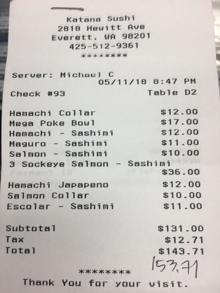
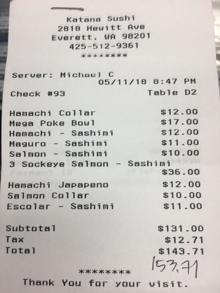
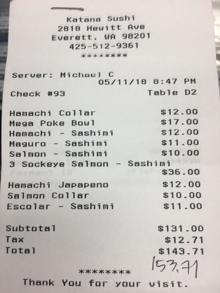
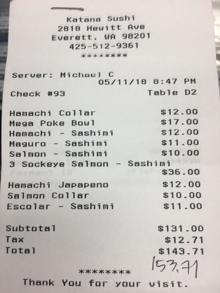
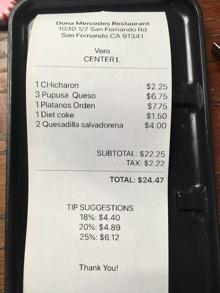
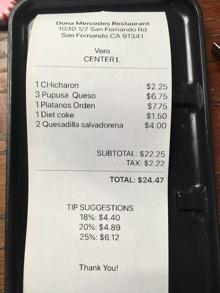
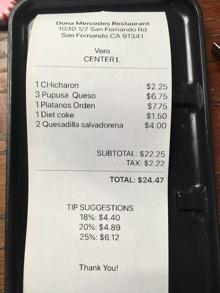
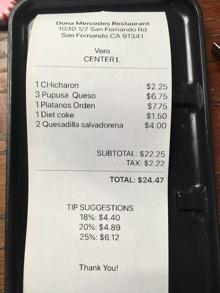
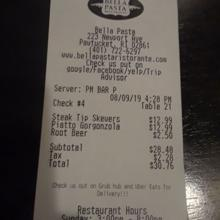
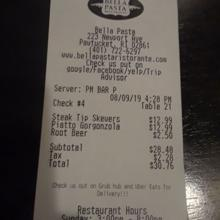
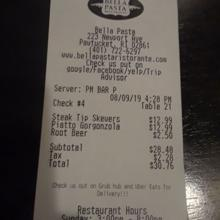
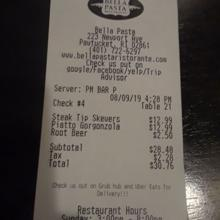

In [12]:
sample_receipts = list_receipt_images(preferred_receipts_dir())[:3]
batch_rows = []

for image_path in sample_receipts:
    for config in pipeline_configs:
        result = run_pipeline_config(image_path, config, run_control=run_control)
        batch_rows.append({
            "image": thumbnail_html(image_path),
            "receipt": image_path.name,
            "label": result["label"],
            "perception_method": result["perception_method"],
            "planning_version": result["planning_version"],
            "parsed_text": parsed_text_html(result["ocr_result"].text) if result["status"] == "ok" else None,
            "status": result["status"],
            "merchant": result["spending_profile"].merchant if result["status"] == "ok" else None,
            "total_amount": result["spending_profile"].total_amount if result["status"] == "ok" else None,
            "line_item_count": len(result["spending_profile"].line_items) if result["status"] == "ok" else None,
            "primary_card": result["recommendation"].primary_card if result["status"] == "ok" and result["recommendation"] else None,
            "estimated_value": result["recommendation"].primary_estimated_value if result["status"] == "ok" and result["recommendation"] else None,
            "error": result["error"],
        })

batch_df = pd.DataFrame(batch_rows, columns=[
    "image",
    "receipt",
    "label",
    "perception_method",
    "planning_version",
    "parsed_text",
    "status",
    "merchant",
    "total_amount",
    "line_item_count",
    "primary_card",
    "estimated_value",
    "error",
])

table_html = batch_df.to_html(escape=False, index=False)
table_html = table_html.replace(
    '<table border="1" class="dataframe">',
    '<table border="1" class="dataframe comparison-table">'
)

display(HTML('''
<style>
.comparison-table td, .comparison-table th {
    vertical-align: top;
    text-align: left;
    padding: 8px;
}
</style>
''' + table_html))
